In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import xarray as xr
import rioxarray
from rasterio.warp import transform_bounds
from rasterio.transform import from_bounds
import numpy as np
import glob
from tqdm import tqdm

In [3]:
from utils.constants import SENTINEL_SCENES_FOLDERPATH, SILVER_FOLDERPATH, GHANA_GDF
from utils.site import Site
from utils.s2item import S2Item
from utils.snapshot import Snapshot

In [4]:
# Load s2items
s2items = S2Item.load_all()
print(f"Loaded {len(s2items)} S2Items")

Loaded 48 S2Items


In [5]:
snapshots = [{
    'R': e.folderpath / f"{e.id}_red.tif",
    'G': e.folderpath / f"{e.id}_green.tif",
    'B': e.folderpath / f"{e.id}_blue.tif",
    'SCL': e.folderpath / f"{e.id}_scl.tif",
} for e in s2items[:10]]

In [6]:
from dask.distributed import Client, LocalCluster

# Set n_workers to match your CPU cores. 
# Set memory_limit to prevent RAM crashes.
cluster = LocalCluster(n_workers=8, threads_per_worker=2, memory_limit='16GB')
client = Client(cluster)
print(f"Dask Dashboard accessible at: {client.dashboard_link}")

Dask Dashboard accessible at: http://127.0.0.1:8787/status


In [7]:
# --- STEP 1: DEFINE THE MASTER GRID ---
# We use a Red band (10m resolution) to define our target standard
template_ds = rioxarray.open_rasterio(snapshots[0]['R'])
target_crs = template_ds.rio.crs
res_x, res_y = abs(template_ds.rio.resolution()[0]), abs(template_ds.rio.resolution()[1])

left, bottom, right, top = float('inf'), float('inf'), float('-inf'), float('-inf')

print("Calculating global bounds across all snapshots...")
for snap in snapshots:
    # Just checking the Red band bounds is sufficient for the snapshot footprint
    with rioxarray.open_rasterio(snap['R']) as ds:
        bounds = transform_bounds(ds.rio.crs, target_crs, *ds.rio.bounds())
        left, bottom = min(left, bounds[0]), min(bottom, bounds[1])
        right, top = max(right, bounds[2]), max(top, bounds[3])

target_width = int((right - left) / res_x)
target_height = int((top - bottom) / res_y)
target_transform = from_bounds(left, bottom, right, top, target_width, target_height)

Calculating global bounds across all snapshots...


In [ ]:
import os
import xarray as xr
import rioxarray
import dask
import numpy as np
from tqdm import tqdm

# --- STEP 2: ALIGN, MASK CLOUDS, AND SAVE TO DISK ---
aligned_dir = 'temp_aligned_ghana_rgb'
os.makedirs(aligned_dir, exist_ok=True)
aligned_files = []
delayed_writes = []  # This will store our lazy parallel write tasks

print("Building parallel task graph for alignment, stacking, and cloud masking...")

# 2048x2048 is ideal for on-the-fly warping
chunk_size = 2048 

# Helper function to lazily load and reproject a single band using Dask
def prep_band(filepath):
    # CRITICAL FIX 1: Pass 'chunks' to force Dask lazy-loading instead of eager RAM loading
    ds = rioxarray.open_rasterio(filepath, chunks={'x': chunk_size, 'y': chunk_size})
    
    if ds.rio.nodata is not None:
        ds = ds.where(ds != ds.rio.nodata)
        
    return ds.rio.reproject(
        target_crs,
        transform=target_transform,
        shape=(target_height, target_width),
        nodata=np.nan
    )

for i, snap in enumerate(snapshots):
    out_path = os.path.join(aligned_dir, f"aligned_rgb_clean_{i}.tif")
    aligned_files.append(out_path)
    
    # Skip if the file was already processed previously
    if os.path.exists(out_path):
        continue
        
    # 1. Lazily define the reprojections (takes microseconds per file)
    r = prep_band(snap['R'])
    g = prep_band(snap['G'])
    b = prep_band(snap['B'])
    scl = prep_band(snap['SCL'])
    
    # 2. Stack channels
    rgb_stack = xr.concat([r, g, b], dim='band')
    
    # 3. Define cloud mask
    valid_pixels = (scl != 8) & (scl != 9)
    valid_pixels = valid_pixels.squeeze(drop=True) 
    
    # 4. Apply mask lazily
    rgb_clean = rgb_stack.where(valid_pixels)
    
    # 5. CRITICAL FIX 2: Pass `compute=False`. This tells rioxarray NOT to execute yet,
    # but rather to generate a lightweight blueprint task for the LocalCluster.
    delayed_task = rgb_clean.rio.to_raster(
        out_path, 
        compress='lzw', 
        tiled=True, 
        windowed=True,
        compute=False
    )
    delayed_writes.append(delayed_task)

# --- EXECUTE IN PARALLEL ---
if delayed_writes:
    print(f"Triggering parallel processing for {len(delayed_writes)} snapshots across the LocalCluster...")
    
    # CRITICAL FIX 3: This fires up all your workers simultaneously. Because each snapshot
    # writes to its own separate file, there are no file-lock collisions!
    dask.compute(*delayed_writes)
else:
    print("All snapshots were already pre-aligned on disk. Skipping computation.")

print("All snapshots aligned, cloud-masked, and saved to disk successfully!")

Building parallel task graph for alignment, stacking, and cloud masking...


In [9]:
# --- STEP 3: CALCULATE MEDIAN ON CLEAN MULTI-BAND FILES ---
print("Building lightweight Dask graph for RGB median calculation...")

aligned_rasters = []
chunk_size = 1024 # Slightly smaller chunks for 3-band data to save RAM

for file in aligned_files:
    ds = rioxarray.open_rasterio(file, chunks={'x': chunk_size, 'y': chunk_size})
    aligned_rasters.append(ds)

# Stack along the 'image' dimension
stacked = xr.concat(aligned_rasters, dim='image')

# Rechunk for deep median math across all bands and images
stacked = stacked.chunk({'image': -1, 'band': -1, 'x': 512, 'y': 512})

# Calculate median. It will process all 3 bands independently!
median_composite = stacked.median(dim='image', skipna=True)
median_composite.rio.write_crs(target_crs, inplace=True)
median_composite.rio.write_nodata(np.nan, inplace=True)

Building lightweight Dask graph for RGB median calculation...


<xarray.DataArray (band: 3, y: 10980, x: 20976)> Size: 3GB
dask.array<nanmedian, shape=(3, 10980, 20976), dtype=float32, chunksize=(3, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 88kB 7e+05 7e+05 7e+05 ... 5.902e+05 5.902e+05
  * x            (x) float64 168kB 6e+05 6e+05 6e+05 ... 8.097e+05 8.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          nan
    scale_factor:        1.0
    add_offset:          0.0

In [12]:
# --- STEP 4: COMPUTE AND WRITE TO DISK ---
print("Computing and writing final 3-band RGB composite...")

# CRITICAL FIX: Use the cluster-aware distributed lock
from dask.distributed import Lock as DistributedLock

# Create a cross-process lock managed by the Dask Scheduler
cluster_lock = DistributedLock("ghana-geotiff-writer")

median_composite.rio.to_raster(
    'ghana_rgb_median_composite_cloudfree.tif',
    tiled=True,
    windowed=True,
    compress='lzw',
    
    # Drop block size slightly to 512 to reduce RAM footprint per worker write
    blockxsize=512,
    blockysize=512,
    
    # Pass the cross-process lock here
    lock=cluster_lock
)

print("Cloud-free RGB composite created successfully!")

Computing and writing final 3-band RGB composite...
Cloud-free RGB composite created successfully!


In [7]:
import rioxarray
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the final cloud-free composite
# 'masked=True' converts nodata and remaining cloud holes into NaNs
da = rioxarray.open_rasterio('ghana_rgb_median_composite_cloudfree.tif', masked=True)

# 2. Downsample for plotting speed 
# Takes every 20th pixel for the visual preview so it loads instantly.
# Change this to 10 or 5 if you want a sharper image and your RAM allows it.
downsample_factor = 100
da_resampled = da.coarsen(x=downsample_factor, y=downsample_factor, boundary='trim').mean()

# 3. Transpose dimensions from (band, y, x) to (y, x, band) for matplotlib
rgb_array = da_resampled.transpose('y', 'x', 'band').values

# 4. Apply a Percentile Contrast Stretch (Enhances colors and highlights)
def contrast_stretch(img):
    stretched_img = np.zeros_like(img)
    for b in range(img.shape[2]): # Loop through Red, Green, Blue bands
        band = img[:, :, b]
        
        # Calculate 2nd and 98th percentile, ignoring NaN values
        p2, p98 = np.nanpercentile(band, [2, 98])
        
        # Scale the pixel values strictly between 0 and 1 based on percentiles
        if p98 > p2:
            band_stretched = (band - p2) / (p98 - p2)
        else:
            band_stretched = band
            
        stretched_img[:, :, b] = np.clip(band_stretched, 0, 1)
        
    return stretched_img

print("Enhancing image contrast...")
rgb_stretched = contrast_stretch(rgb_array)

# 5. Fill empty space (Replace any remaining NaN borders/holes with black)
rgb_final = np.nan_to_num(rgb_stretched, nan=0.0)

# 6. Render the Map
print("Rendering plot...")
plt.figure(figsize=(12, 14))
plt.imshow(rgb_final)

plt.title('Cloud-Free RGB Median Composite of Ghana', fontsize=16, fontweight='bold', pad=15)
plt.axis('off') # Hide pixel coordinates for a clean map presentation
plt.show()

RasterioIOError: ghana_rgb_median_composite_cloudfree.tif: No such file or directory

Enhancing image contrast...
Rendering plot...


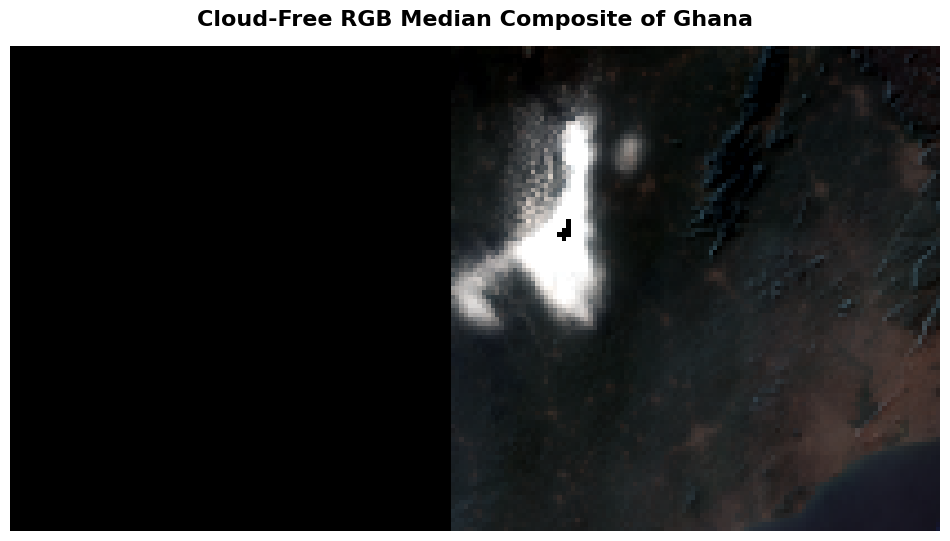

In [19]:
import rioxarray
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the final cloud-free composite
# 'masked=True' converts nodata and remaining cloud holes into NaNs
da = rioxarray.open_rasterio('temp_aligned_ghana_rgb/aligned_rgb_clean_1.tif', masked=True)

# 2. Downsample for plotting speed 
# Takes every 20th pixel for the visual preview so it loads instantly.
# Change this to 10 or 5 if you want a sharper image and your RAM allows it.
downsample_factor = 100
da_resampled = da.coarsen(x=downsample_factor, y=downsample_factor, boundary='trim').mean()

# 3. Transpose dimensions from (band, y, x) to (y, x, band) for matplotlib
rgb_array = da_resampled.transpose('y', 'x', 'band').values

# 4. Apply a Percentile Contrast Stretch (Enhances colors and highlights)
def contrast_stretch(img):
    stretched_img = np.zeros_like(img)
    for b in range(img.shape[2]): # Loop through Red, Green, Blue bands
        band = img[:, :, b]
        
        # Calculate 2nd and 98th percentile, ignoring NaN values
        p2, p98 = np.nanpercentile(band, [2, 98])
        
        # Scale the pixel values strictly between 0 and 1 based on percentiles
        if p98 > p2:
            band_stretched = (band - p2) / (p98 - p2)
        else:
            band_stretched = band
            
        stretched_img[:, :, b] = np.clip(band_stretched, 0, 1)
        
    return stretched_img

print("Enhancing image contrast...")
rgb_stretched = contrast_stretch(rgb_array)

# 5. Fill empty space (Replace any remaining NaN borders/holes with black)
rgb_final = np.nan_to_num(rgb_stretched, nan=0.0)

# 6. Render the Map
print("Rendering plot...")
plt.figure(figsize=(12, 14))
plt.imshow(rgb_final)

plt.title('Cloud-Free RGB Median Composite of Ghana', fontsize=16, fontweight='bold', pad=15)
plt.axis('off') # Hide pixel coordinates for a clean map presentation
plt.show()